In [136]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ( classification_report,confusion_matrix,precision_score,recall_score,f1_score,roc_auc_score)

In [137]:
from sklearn.datasets import fetch_openml

dataset = fetch_openml(
    name="mammography",
    version=1,
    as_frame=True
)

X = dataset.data
y = dataset.target

print(X.shape)
print(y.value_counts())

(11183, 6)
class
-1    10923
1       260
Name: count, dtype: int64


In [138]:
print(type(dataset))

<class 'sklearn.utils._bunch.Bunch'>


In [139]:
df = X.copy()
df["Class"] = y

In [140]:
print("Dataset Shape:", df.shape)

Dataset Shape: (11183, 7)


In [141]:
df.head()

,attr1,attr2,attr3,attr4,attr5,attr6,Class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,-1
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,-1
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,-1
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,-1
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,-1


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11183 entries, 0 to 11182
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   attr1   11183 non-null  float64 
 1   attr2   11183 non-null  float64 
 2   attr3   11183 non-null  float64 
 3   attr4   11183 non-null  float64 
 4   attr5   11183 non-null  float64 
 5   attr6   11183 non-null  float64 
 6   Class   11183 non-null  category
dtypes: category(1), float64(6)
memory usage: 535.4 KB


In [143]:
df.describe()

,attr1,attr2,attr3,attr4,attr5,attr6
count,1.118300e+04,1.118300e+04,1.118300e+04,1.118300e+04,1.118300e+04,1.118300e+04
mean,1.096536e-10,1.297595e-09,5.698113e-10,-2.435706e-09,-1.120680e-09,1.459483e-09
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-7.844148e-01,-4.701953e-01,-5.916315e-01,-8.595525e-01,-3.778657e-01,-9.457232e-01
25%,-7.844148e-01,-4.701953e-01,-5.916315e-01,-8.595525e-01,-3.778657e-01,-9.457232e-01
50%,-1.085769e-01,-3.949941e-01,-2.309790e-01,-8.595525e-01,-3.778657e-01,-9.457232e-01
75%,3.139489e-01,-7.649473e-02,2.198366e-01,8.202077e-01,-3.778657e-01,1.016613e+00
max,3.150844e+01,5.085849e+00,2.947777e+01,9.591164e+00,2.361712e+01,1.949027e+00


In [144]:
print(df.dtypes)

attr1     float64
attr2     float64
attr3     float64
attr4     float64
attr5     float64
attr6     float64
Class    category
dtype: object


In [145]:
print(df.isnull().sum())     #data exploration
df = df.dropna()     #drop missing value

attr1    0
attr2    0
attr3    0
attr4    0
attr5    0
attr6    0
Class    0
dtype: int64


In [146]:
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate Rows: 3334


In [147]:
print("After:", len(df))


After: 7849


Class
-1    7595
1      254
Name: count, dtype: int64


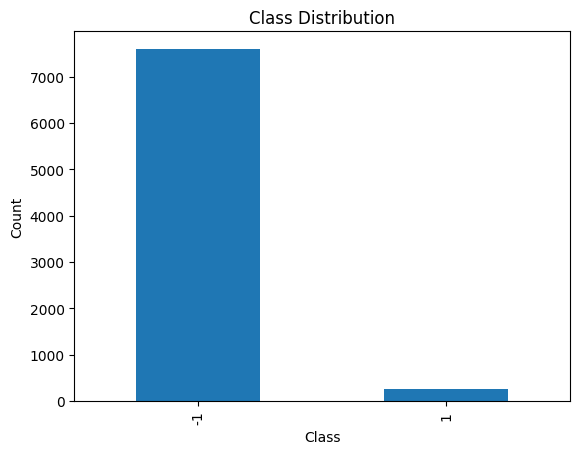

In [148]:
print(df["Class"].value_counts())
df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [149]:
y = dataset.target.copy()

# Convert category to string
y = y.astype(str)

# Map labels
y = y.map({
    '-1': 0,
    '1': 1
})

print(y.unique())
print(y.value_counts())
print(y.isna().sum())

[0 1]
class
0    10923
1      260
Name: count, dtype: int64
0


In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test, 80% train
    stratify=y,          # ensures class balance in both sets
    random_state=42      # reproducibility
)




In [151]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [161]:
model = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    max_samples='auto',
    random_state=42
)

model.fit(X_train_scaled)

IsolationForest(contamination=0.03, n_estimators=300, random_state=42)

In [165]:
df = df.copy()
# Ensure 'anomaly_score' and 'prediction' are not in df before creating X_for_prediction
if 'anomaly_score' in df.columns:
    df = df.drop('anomaly_score', axis=1)
if 'prediction' in df.columns:
    df = df.drop('prediction', axis=1)

# Create X from the current (deduplicated) df to ensure consistent length
X_for_prediction = df.drop("Class", axis=1)
# Scale X_for_prediction using the previously fitted scaler
X_for_prediction_scaled = scaler.transform(X_for_prediction)
df["anomaly_score"] = model.decision_function(X_for_prediction_scaled)
df["prediction"] = model.predict(X_for_prediction_scaled)

In [154]:
df["prediction"].value_counts()

,count
prediction,
1,7513
-1,336


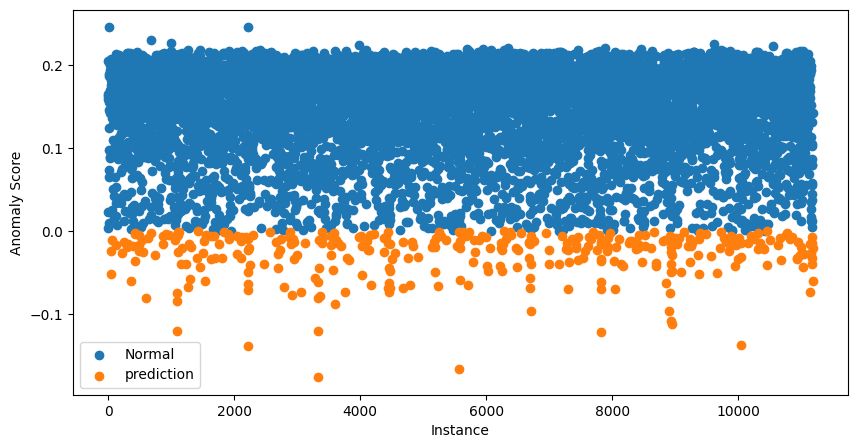

In [155]:
# Visualization of the results
plt.figure(figsize=(10, 5))

# Plot normal instances
normal = df[df['prediction'] == 1]
plt.scatter(normal.index, normal['anomaly_score'], label='Normal')

# Plot anomalies
anomalies = df[df['prediction'] == -1]
plt.scatter(anomalies.index, anomalies['anomaly_score'], label='prediction')
plt.xlabel("Instance")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

In [156]:
print(y.dtype)
print(y.unique())
print(y.isnull().sum())

int64
[0 1]
0


In [167]:
pred = model.predict(X_for_prediction_scaled)
pred = np.where(pred == -1, 1, 0)

# Create y_true for the deduplicated df, consistent with how y was mapped
y_true_deduplicated = df['Class'].astype(str).map({'-1': 0, '1': 1})

precision = precision_score(y_true_deduplicated, pred)
recall = recall_score(y_true_deduplicated, pred)
f1 = f1_score(y_true_deduplicated, pred)
scores = -model.decision_function(X_for_prediction_scaled)

roc_auc = roc_auc_score(y_true_deduplicated, scores)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

Precision: 0.18895348837209303
Recall: 0.2559055118110236
F1 Score: 0.21739130434782608
ROC AUC Score: 0.8213793264321222


In [158]:
print(classification_report(y_true_deduplicated,pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      7595
           1       0.20      0.27      0.23       254

    accuracy                           0.94      7849
   macro avg       0.59      0.62      0.60      7849
weighted avg       0.95      0.94      0.95      7849



In [159]:
cm = confusion_matrix(y_true_deduplicated,pred)
print(cm)

[[7327  268]
 [ 186   68]]


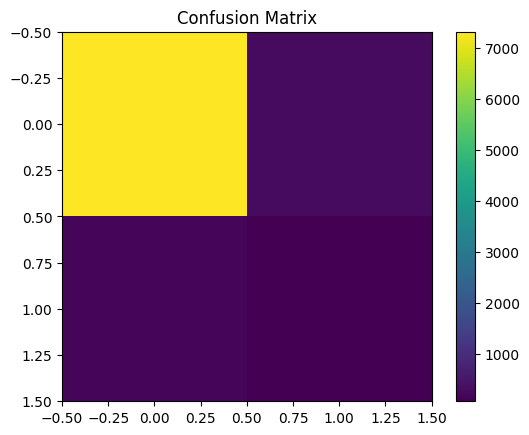

In [160]:
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()